# Simple Pairs Trading Independent Project - KO and PEP

## Preliminaries

In [5]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.tsa.vector_ar.vecm import VECM
import yfinance as yf
import warnings
from statsmodels.tsa.statespace.mlemodel import MLEModel
import statsmodels.tsa.statespace.initialization as init
from arch import arch_model
warnings.filterwarnings("ignore")

In [6]:
prices = yf.download(
    ["KO", "PEP"],
    period="10y", 
    interval="1d",
    auto_adjust=True,
    progress=False
)["Close"]

prices = prices.dropna()

print(prices.head())

prices.to_csv("KO_PEP_prices.csv")

Ticker             KO        PEP
Date                            
2016-08-15  32.377022  80.044495
2016-08-16  32.076954  79.514366
2016-08-17  32.245293  79.860405
2016-08-18  32.274559  79.720535
2016-08-19  32.142826  79.639557


Using the natural logarithm of prices is commonplace to convert multiplicative price dynamics into an additive form, giving continously compounded returns if you take returns of the log prices.

In [8]:
log_prices = np.log(prices)
# In and out of sample split
log_prices_train = log_prices.loc["2016-06-03":"2023-06-03"]
log_prices_train

Ticker,KO,PEP
Date,,
2016-08-15,3.477449,4.382583
2016-08-16,3.468138,4.375938
2016-08-17,3.473372,4.380280
2016-08-18,3.474279,4.378527
2016-08-19,3.470189,4.377511
...,...,...
2023-05-26,4.002799,5.101017
2023-05-30,3.994802,5.090228
2023-05-31,3.992792,5.094295


## Determining relationship between two assets - establishing simple pairs trading strategy

One effective method in which we can determine whether there is meaningful  error correcting relationship in the long run is the VECM representation framework of Granger-Johansen. This works by stacking the process into a cointegrated VAR(1) system. From there we rewrite this in terms of first differences, which gives the full VECM representation. $\gamma$ is then derived from this long-run equilibrium relationship. This full derivation is illustrated below.

## The Vector Error Correction Model (VECM) Representation

To formally analyze the long-run equilibrium and short-run dynamic adjustments between Coca-Cola ($\ln(\text{KO}_t)$) and Pepsi ($\ln(\text{PEP}_t)$), the Granger-Johansen Vector Error Correction Model (VECM) framework can be utilized.

We begin by defining our $K$-dimensional vector of endogenous variables ($K=2$) containing our log prices:
$$Y_t = \begin{bmatrix} \ln(\text{KO}_t) \\ \ln(\text{PEP}_t) \end{bmatrix}$$

Assuming $Y_t$ follows a Vector Autoregressive process of order $p$, a $\text{VAR}(p)$ system can be written as:
$$Y_t = \nu + \sum_{i=1}^{p} A_i Y_{t-i} + u_t$$

where $\nu$ is a vector of deterministic constants and $u_t \sim \operatorname{w.u.n.}(\mathbf{0}, \Sigma)$ represents white noise innovations. Following Granger's Representation Theorem, if the variables in $Y_t$ are integrated of order one, $I(1)$ - meaning they can be differenced once to form a weakly stationary $I(0)$ process - and if they are cointegrated with a cointegrating rank $r$, the system can be rewritten in its first-difference VECM representation (setting our lag length in first-differences to $k_{\text{ar\_diff}} = p-1 = 1$:

$$\Delta Y_t = \nu + \Pi Y_{t-1} + \Gamma_1 \Delta Y_{t-1} + u_t$$

Where:
* $\Delta Y_t = Y_t - Y_{t-1} = \begin{bmatrix} \Delta \ln(\text{KO}_t) \\ \Delta \ln(\text{PEP}_t) \end{bmatrix}$ is the vector of continuously compounded returns.
* $\Gamma_1 = -\sum_{j=2}^{p} A_j$ captures the short-run transient dynamics of the system.
* $\Pi = \left(\sum_{i=1}^{p} A_i\right) - I_K$ is the long-run impact matrix that contains the cointegrating structural parameters.

#### Decomposition of the Impact Matrix $\Pi$ and the Error Correction Mechanism

If the system is cointegrated with a rank deficiency condition of $\operatorname{rank}(\Pi) = r = 1$, the matrix $\Pi$ can be decomposed into the product of two distinct $2 \times 1$ matrices, $\alpha$ and $\beta$:
$$\Pi = \alpha \beta'$$

Substituting this decomposition back into our VECM representation yields:
$$\Delta Y_t = \nu + \alpha \left( \beta' Y_{t-1} \right) + \Gamma_1 \Delta Y_{t-1} + u_t$$

Expanding this system explicitly into its structural parameters allows us to parse out the individual equations:

$$\begin{bmatrix} \Delta \ln(\text{KO}_t) \\ \Delta \ln(\text{PEP}_t) \end{bmatrix} = \begin{bmatrix} \nu_1 \\ \nu_2 \end{bmatrix} + \begin{bmatrix} \alpha_1 \\ \alpha_2 \end{bmatrix} \left( \begin{bmatrix} 1 & \gamma \end{bmatrix} \begin{bmatrix} \ln(\text{KO}_{t-1}) \\ \ln(\text{PEP}_{t-1}) \end{bmatrix} \right) + \Gamma_1 \begin{bmatrix} \Delta \ln(\text{KO}_{t-1}) \\ \Delta \ln(\text{PEP}_{t-1}) \end{bmatrix} + \begin{bmatrix} u_{1,t} \\ u_{2,t} \end{bmatrix}$$

Where:
1. **The Cointegrating Vector ($\beta'$):** $$\beta' = \begin{bmatrix} 1 & \gamma \end{bmatrix}$$
   This vector represents the long-run equilibrium relationship. Normalized with respect to KO, the term inside the parentheses defines our stationary long-run residual spread: 
   $$s_{t-1} = \beta' Y_{t-1} = \ln(\text{KO}_{t-1}) + \gamma \ln(\text{PEP}_{t-1})$$
   *(Note: This aligns with our subsequent empirical Johansen estimation where $\gamma \approx -0.7924$, matching the structural spread formulation $\ln(\text{KO}_t) - 0.7924\ln(\text{PEP}_t)$).*

2. **The Speed of Adjustment Vector ($\alpha$):**
   $$\alpha = \begin{bmatrix} \alpha_1 \\ \alpha_2 \end{bmatrix}$$
   The coefficients $\alpha_1$ and $\alpha_2$ dictate the error-correcting feedback mechanism (the speed of adjustment). They measure how fast each asset's return reacts to clear out historical deviations from the long-run equilibrium spread. For the system to stably mean-revert, $\alpha_1$ must be negative, dragging the price of KO downward when the spread is positively overextended, while $\alpha_2$ should ideally be positive to pull PEP upward.


The residual spread at time t is given by $s_t = \beta'Y_t = ln(KO_t)$ + $\gamma ln(PEP_t)$ where $\gamma$ is the hedging ratio.

### Johansen (1998) - Trace and Maximum Eigenvalue Tests

There are two main statistical tests available to hypothesis test the exact number of cointegrating relations present - the trace and max eigenvalues tests of Johansen (1998).
#### Trace test ####
Trace test uses the following test statistic:
#### $-T\cdot\Sigma_{i=r+1}^{n} \ln(1-\lambda_{i})$
where $T$ is the sample size, $\lambda_i$ is eigenvalues of estimated matrix of cointegrating row vectors and $r$ is the number of cointegrating relations. The null hypothesis of the trace test is that there is a number of cointegrating relations that is less than or equal to a given number $r$. This hypothesis test is applied iteratively for different values of $r$ until we fail to reject the null hypothesis.

In [15]:
johansen_result = coint_johansen(log_prices_train[["KO", "PEP"]], det_order=0, k_ar_diff=1) # Johansen tests of trace & max eigenvalue
# det_order = 0 gives constant term (intercept), k_ar_diff = 1 is the number of lags we have chosen to rewrite in terms of first differences
# Print Trace test result for number of cointegrating relations
print("--- JOHANSEN TRACE TEST RESULTS ---")
print("Rank | Trace Stat | Critical Values (90%, 95%, 99%)")
print("-" * 55)
for i in range(len(johansen_result.lr1)):
    print(f"r <= {i} | {johansen_result.lr1[i]:.4f}     | {johansen_result.cvt[i]}")

--- JOHANSEN TRACE TEST RESULTS ---
Rank | Trace Stat | Critical Values (90%, 95%, 99%)
-------------------------------------------------------
r <= 0 | 14.4933     | [13.4294 15.4943 19.9349]
r <= 1 | 0.2398     | [2.7055 3.8415 6.6349]


The trace test for rank <= 0 has a trace test statistic that is significant at the 95% confidence level, meaning we reject the null of no cointegrating relation (at 5% significance level).
The trace test for rank <= 1 has a trace test statistic that is not statistically significant, so we fail to reject the null of one cointegrating relation.

Thus, the implication from the trace test is that there is at most one cointegrating relation (with 95% confidence).

#### Max eigenvalues test

The maximum eigenvalue test uses following test statistic:

$-T \cdot ln(1-\lambda_{r+1})$, 

where $T$ is sample size and $\lambda_{r+1}$ is the $r+1^{th}$ largest eigenvalue when eigenvalues are ordered from smallest to largest. The test evaluates a null hypothesis that the number of cointegrating relations is exactly equal to $r$ against an alternative hypothesis of $r+1$ cointegrating relations. Similar to the trace test, this hypothesis test is applied iteratively, i.e. for r = 0 vs r = 1, then for r = 1 vs r = 2 etc. until we fail to reject the null hypothesis.

In [19]:
print("--- JOHANSEN MAXIMUM EIGENVALUE TEST RESULTS ---")
print("Hypothesis Test | Max Eigenvalue Stat | Critical Values (90%, 95%, 99%)")
print("-" * 55)
for i in range(len(johansen_result.max_eig_stat)):
    print(f"r = {i} vs r = {i+1} | {johansen_result.max_eig_stat[i]:.4f}     | {johansen_result.max_eig_stat_crit_vals[i]}")
print("="*55)

--- JOHANSEN MAXIMUM EIGENVALUE TEST RESULTS ---
Hypothesis Test | Max Eigenvalue Stat | Critical Values (90%, 95%, 99%)
-------------------------------------------------------
r = 0 vs r = 1 | 14.2535     | [12.2971 14.2639 18.52  ]
r = 1 vs r = 2 | 0.2398     | [2.7055 3.8415 6.6349]


The maximum eigenvalue test of null of no cointegration relations against alternative of one cointegration relation has a test statistic that is significant at 95% confidence level. So we reject the null of no cointegrating relations.

The maximum eigenvalue test of null of one cointegrating relation against alternative of two cointegrating relations has a test statistic that is not statistically significant, so we fail to reject null of one cointegrating relation.

The implication from the maximum eigenvalue test is thus also that there is at most one cointegrating relation (with 95% confidence). Both tests happen to agree in this case and imply there is exactly one cointegrating relation.

In [21]:
vecm_result = VECM(endog=log_prices_train[["KO", "PEP"]], k_ar_diff=1, coint_rank=1, deterministic = 'ci').fit() # Fit the entire VECM representation
# coint_rank = 1 is the rank of the cointegrating matrix when we fit the VECM since we just found one cointegrating relation 

In [22]:
print("Alpha estimates in VECM representation:")
vecm_result.alpha # estimates for alpha coefficients in Pi matrix (speed of adjustment) in VECM representation

Alpha estimates in VECM representation:


array([[-0.02229149],
       [-0.01016824]])

In [23]:
print("Beta estimates in VECM representation:")
vecm_result.beta # estimates for beta coefficients in Pi matrix in VECM representation

Beta estimates in VECM representation:


array([[ 1.        ],
       [-0.78259746]])

In [24]:
# Print the raw eigenvectors for reference
print("--- EIGENVECTORS MATRIX (for reference) ---")
print(johansen_result.evec) # contains estimated cointegrating vectors

--- EIGENVECTORS MATRIX (for reference) ---
[[ 22.10867558  -1.37765033]
 [-17.33523479   5.34428097]]


Since we earlier concluded there is at most one cointegrating relation ($rank(\Pi) = 1$), it is the first column of the eigenvectors matrix that gives the estimated cointegrating vector for this example. First $\beta'$ vector is $[22.25627153, -17.63629811]'$. 

It is standard practice to normalize this vector as the cointegrating vector is not unique in scale (scaling it through by a constant would produce a vector that represents exactly the same cointegrating relationship). Normalizing the vector means dividing through by 22.25627153 in this case, making the first element equal to 1. This gives a normalised vector of $\beta'$ = $[1,- 0.7924 (4.d.p)]'$, which implies a hedging ratio of $\gamma$ = 0.7924 given earlier we defined spread as **$s_t$ = $\beta'y_t$ = $ln(KO_t)$ - $\gamma$$ln(PEP_t)$** for log price vector $y_t$. This aligns with what we have just computed from the full VECM representation.

In [26]:
# Compute the above
cointegrating_vectors = johansen_result.evec
cointegrating_rowvectors = cointegrating_vectors.T
estimated_cointvector = cointegrating_rowvectors[0]
estimated_cointvector_normal = estimated_cointvector/estimated_cointvector[0]
gamma = estimated_cointvector_normal[1].item()
log_prices_train["Spread"] = log_prices_train["KO"] + gamma*log_prices_train["PEP"]
mean_train_spread = log_prices_train["Spread"].mean()
std_train_spread = log_prices_train["Spread"].std()
log_prices_train

Ticker,KO,PEP,Spread
Date,,,
2016-08-15,3.477449,4.382583,0.041101
2016-08-16,3.468138,4.375938,0.037000
2016-08-17,3.473372,4.380280,0.038830
2016-08-18,3.474279,4.378527,0.041111
2016-08-19,3.470189,4.377511,0.037818
...,...,...,...
2023-05-26,4.002799,5.101017,0.003132
2023-05-30,3.994802,5.090228,0.003595
2023-05-31,3.992792,5.094295,-0.001603


## Out of sample backtest for spread derived from VECM representation

The following segment conducts an out of sample backtest on the residual spread derived from the VECM representation. 

In [29]:
# Test (out of sample) data
log_prices_test = log_prices.loc["2023-06-03":]
# Compute residual spread
log_prices_test["Spread"] = log_prices_test["KO"] + gamma*log_prices_test["PEP"] 
spread = log_prices_test["Spread"]
train_mean = mean_train_spread  
# Create a function that computes exponential moving weighted average t-statistic using in-sample parameters
def compute_ewma_t_stat(spread_test: pd.Series, train_mean: float, span: int = 63):
    """EWMA t-stat for out-of-sample backtest"""
    t_stat = pd.Series(index=spread_test.index, dtype=float)
    
    for i in range(len(spread_test)):
        if i < 30:                      # Minimum observations for stable EWMA
            t_stat.iloc[i] = np.nan
            continue
            
        # Use only past data up to current point
        past_data = spread_test.iloc[:i+1]
        ewma_std = past_data.ewm(span=span, adjust=False).std().iloc[-1]
        
        t_stat.iloc[i] = (spread_test.iloc[i] - train_mean) / ewma_std if ewma_std > 0 else np.nan
    
    return t_stat

t_stat_bt = compute_ewma_t_stat(spread, train_mean)
t_stat_bt

Date
2023-06-05         NaN
2023-06-06         NaN
2023-06-07         NaN
2023-06-08         NaN
2023-06-09         NaN
                ...   
2026-08-10    7.724692
2026-08-11    7.619397
2026-08-12    7.648023
2026-08-13    7.639658
2026-08-14    7.681326
Length: 802, dtype: float64

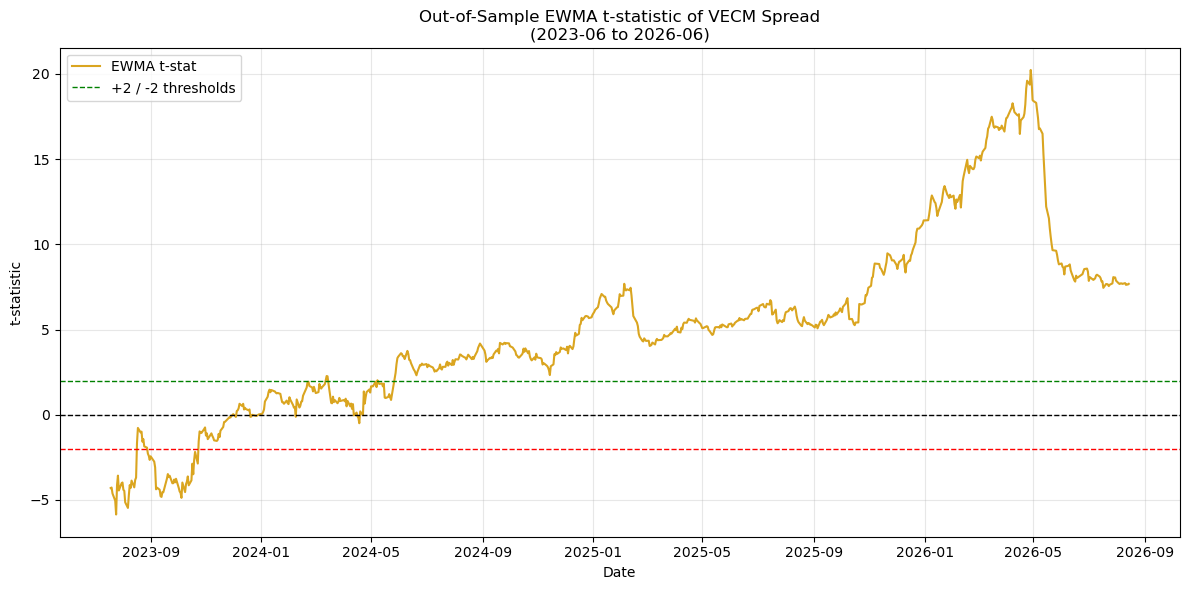

In [30]:
plt.figure(figsize=(12, 6))
plt.style.use("default")

plt.plot(log_prices_test.index, t_stat_bt, color='goldenrod', linewidth=1.5, label='EWMA t-stat')

plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.axhline(y=2, color='green', linestyle='--', linewidth=1, label='+2 / -2 thresholds')
plt.axhline(y=-2, color='red', linestyle='--', linewidth=1)
plt.xlabel("Date")
plt.ylabel("t-statistic")
plt.title("Out-of-Sample EWMA t-statistic of VECM Spread\n(2023-06 to 2026-06)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Aside: In many academic finance papers, a trading strategy is considered legitimate if its t-statistic exceeds 2. However, this rule only works when you test merely one hypothesis. If you test hundreds or thousands, you can find those whose t-statistic exceeds 2 purely by chance. Here we are only testing one basic trading strategy however.

Here, the EWMA t-statistic here greartly exceeds 2 in the out-of-sample (test data) period. This does illustrate the spread has drifted away from the mean spread in the training period.

## Transitioning to State Space Architecture: Local Level Model and Updating via the Kalman Filter

An alternative approach is to treat the relationship between KO and PEP as a dynamic system where the hedge ratio $\gamma_t$ and intercept $\mu_t$ are hidden states that evolve as a random walk process plus noise.

In general, state space models use a measurement (observation) and state (transition) equation to represent these 'hidden states' that evolve over time. Here we can use the simplest type of state space framework (a Local Level model which uses random walk process plus noise) to represent this dynamic process that takes the following form:
#### 1. The Measurement Equation (Observation)
$$\ln(\text{KO}_t) = \begin{bmatrix} \ln(\text{PEP}_t) & 1 \end{bmatrix} \begin{bmatrix} \gamma_t \\ \mu_t \end{bmatrix} + \nu_t, \quad \nu_t \sim N(0, R_t)$$

Where:
* $Y_t = \ln(\text{KO}_t)$ is the scalar observation.
* $H_t = \begin{bmatrix} \ln(\text{PEP}_t) & 1 \end{bmatrix}$ is the time-varying observation matrix.
* $X_t = \begin{bmatrix} \gamma_t & \mu_t \end{bmatrix}'$ is the hidden state vector.
* $R_t$ is the observation noise variance (a scalar).

#### 2. The State Equation (Transition)
This governs how the hidden states evolve from time $t-1$ to $t$:

$$\begin{bmatrix} \gamma_t \\ \mu_t \end{bmatrix} = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix} \begin{bmatrix} \gamma_{t-1} \\ \mu_{t-1} \end{bmatrix} + \eta_t, \quad \eta_t \sim N(0, \mathbf{Q}_t)$$

Where:
* $\mathbf{Q}_t = \begin{bmatrix} \sigma^2_{\gamma} & 0 \\ 0 & \sigma^2_{\mu} \end{bmatrix}$ is the process noise covariance matrix, which dictates how fast the relationship is allowed to drift.

In [34]:
# Create an object through OOP that represents this state space model
class DynamicPairsModel(MLEModel):
    def __init__(self, endog, exog):
        nobs = len(endog)
        
        # k_states=2 (intercept, hedge ratio), k_posdef=2 (two structural shocks)
        super(DynamicPairsModel, self).__init__(
            endog, exog=exog, k_states=2, k_posdef=2, initialization='approximate_diffuse'
        )
        
        # Initialize matrices with explicit time dimension shapes
        # Transition & selection matrices remain static across time
        self['transition'] = np.eye(2)
        self['selection'] = np.eye(2)
        
        # Allocate space for the time-dimension in the design matrix (H)
        # Shape: (k_endog, k_states, nobs) -> (1, 2, nobs)
        self.ssm.design = np.zeros((1, 2, nobs))

    @property
    def param_names(self):
        return ['sigma2_obs', 'sigma2_alpha_drift', 'sigma2_beta_drift']

    @property
    def start_params(self):
        # Good starting log-likelihood variance baselines
        return [0.001, 0.0001, 0.0001]

    def update(self, params, **kwargs):
        params = super(DynamicPairsModel, self).update(params, **kwargs)
        
        # Assign variances to the state space matrices
        self['obs_cov', 0, 0] = params[0]        # R matrix
        self['state_cov', 0, 0] = params[1]       # Q matrix (Intercept variance)
        self['state_cov', 1, 1] = params[2]       # Q matrix (Hedge Ratio variance)
        
        # Cleanly flatten exog into a 1D sequence
        pep_values = np.squeeze(self.exog)
        
        # Now broadcasting will succeed perfectly into the pre-allocated (1, 2, nobs) array
        self['design', 0, 0, :] = 1.0
        self['design', 0, 1, :] = pep_values

In [35]:
kf_model = DynamicPairsModel(endog=log_prices_test["KO"], exog = log_prices_test["PEP"])
# Use our VECM results as prior (initial) state values
initial_beta = 0.7915
initial_alpha = mean_train_spread 

kf_model.initialize_known(
    initial_state=np.array([initial_alpha, initial_beta]),
    # Set a small initial covariance matrix so the filter trusts these starting points
    initial_state_cov=np.eye(2) * 0.0001 
)

# Now smooth or fit the model
kf_results = kf_model.fit()

In [36]:
kf_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Statespace Model Results                           
==============================================================================
Dep. Variable:                     KO   No. Observations:                  802
Model:              DynamicPairsModel   Log Likelihood                1432.356
Date:                Fri, 14 Aug 2026   AIC                          -2858.712
Time:                        19:41:32   BIC                          -2844.650
Sample:                             0   HQIC                         -2853.311
                                - 802                                         
Covariance Type:                  opg                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
sigma2_obs             0.0010      0.004      0.257      0.797      -0.007       0.009
sigma2_alpha_drift     0.0001      0.006      0.017      0.987      -0.012       0.012
sigma2_beta_drift      0.0001      0.000      0.339      0.735      -0.000       0.001
===================================================================================
Ljung-Box (L1) (Q):                  44.08   Jarque-Bera (JB):              3869.20
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.62   Skew:                            -0.85
Prob(H) (two-sided):                  0.00   Kurtosis:                        13.63
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

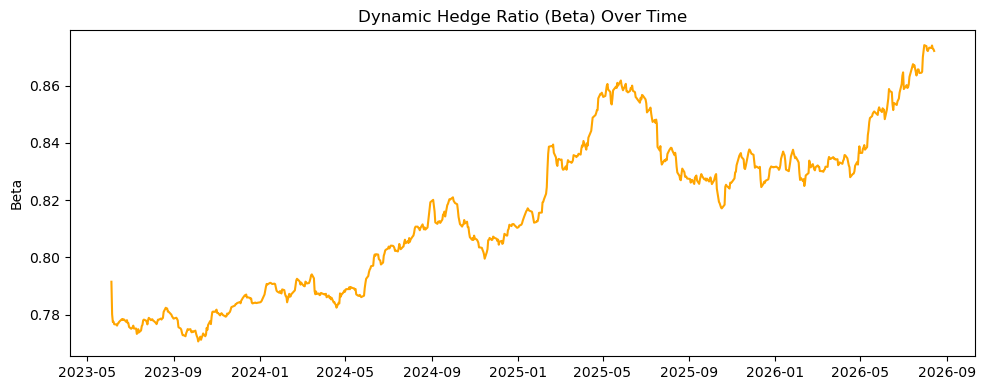

In [72]:
log_prices_test["Predicted_Alpha"] = kf_results.predicted_state[0, :-1]
log_prices_test["Predicted_Beta"] = kf_results.predicted_state[1, :-1]
plt.figure(figsize=(10, 4))
plt.subplots_adjust(top=0.85)
plt.plot(log_prices_test.index, log_prices_test["Predicted_Beta"], color='orange')
plt.title("Dynamic Hedge Ratio (Beta) Over Time")
plt.ylabel("Beta")
plt.tight_layout()
plt.show()

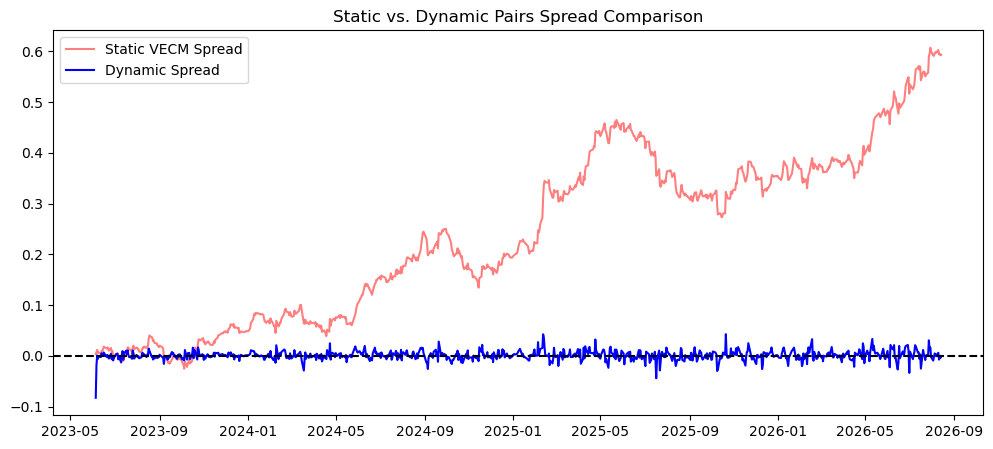

In [74]:
# Dynamic Spread: y_t - (alpha_t + beta_t * x_t)
log_prices_test["Dynamic_Spread"] = log_prices_test["KO"] - (
    log_prices_test["Predicted_Alpha"] + log_prices_test["Predicted_Beta"] * log_prices_test["PEP"]
)

# Plot them side-by-side
plt.figure(figsize=(12, 5))
plt.plot(log_prices_test.index, log_prices_test["Spread"], color='red', alpha=0.5, label='Static VECM Spread')
plt.plot(log_prices_test.index, log_prices_test["Dynamic_Spread"], color='blue', label='Dynamic Spread')
plt.axhline(0, color='black', linestyle='--')
plt.title("Static vs. Dynamic Pairs Spread Comparison")
plt.legend()
plt.show()

## Improving State Space Model Fit with Regularization

Earlier when running `.fit()` on our Local Level model, this method of fitting uses maximum likelihood estimation (MLE) to estimate the parameter that makes the observed data most probable, that is,
#### $$\hat{\theta} = \operatorname{argmax}_{\theta} \ln \left(\mathbb{P}(Y_t \mid \theta)\right),$$
which uses the fact that the natural logarithmic function - being strictly monotone - preserves the argument maximizer of the original objective function.

However, in this case, due to the exploding EWMA $t$-statistic demonstrated earlier, the conditional log-likelihood function's surface becomes flat. The gradients of the conditional log-likelihood $\nabla \ln \mathbb{P}(Y_t \mid \theta) \approx \mathbf{0}$ (a vanishing gradient) become ill-conditioned, causing the optimization algorithm to stall and return the exact starting parameters.

Regularization techniques can help remedy this issue. These methods deal with overfitting by discouraging the model's cost function from augmenting overly complex patterns in the training data. There are two canonical choices for the penalty term in regularization: Lasso ($L_1$) and Ridge ($L_2$) regularization. The penalty term in Lasso regularization promotes sparsity and sets some of the coefficients exactly equal to zero, such that the model ends up effectively performing feature selection. This behaviour is not what we desire in this case. 

Conversely, the penalty term in Ridge regularization shrinks the coefficients of the model smoothly towards zero. Thus, Ridge regularization may help with fitting the model in this case. A Ridge regularization penalty term is, in fact, equivalent to fitting maximum likelihood estimation under the assumption of an isotropic Gaussian prior. The Ridge regularization penalty term is proportional to the sum of the squared coefficients of the features, taking the following form when added to the log-likelihood objective: 
$$\text{Ridge ($L_2$) Penalty Term} = -\lambda \|\theta\|_2^2 = -\lambda \sum_{i=1}^{d} \theta_i^2$$


In [76]:
class RegularizedDynamicPairsModel(MLEModel):
    def __init__(self, endog, exog, l2_lambda=0.05):
        nobs = len(endog)
        self.l2_lambda = l2_lambda  # Regularization hyperparameter
        
        super(RegularizedDynamicPairsModel, self).__init__(
            endog, exog=exog, k_states=2, k_posdef=2, initialization='approximate_diffuse'
        )
        
        self['transition'] = np.eye(2)
        self['selection'] = np.eye(2)
        self.ssm.design = np.zeros((1, 2, nobs))

    @property
    def param_names(self):
        return ['sigma2_obs', 'sigma2_alpha_drift', 'sigma2_beta_drift']

    @property
    def start_params(self):
        return [0.001, 0.0001, 0.0001]

    def update(self, params, **kwargs):
        params = super(RegularizedDynamicPairsModel, self).update(params, **kwargs)
        
        # Enforce positivity constraints on variances using absolute values
        self['obs_cov', 0, 0] = np.abs(params[0])        
        self['state_cov', 0, 0] = np.abs(params[1])       
        self['state_cov', 1, 1] = np.abs(params[2])       
        
        pep_values = np.squeeze(self.exog)
        self['design', 0, 0, :] = 1.0
        self['design', 0, 1, :] = pep_values

    def loglike(self, params, *args, **kwargs):
        """ Injects the L2 Ridge Penalty into the standard log-likelihood objective function """
        base_loglike = super(RegularizedDynamicPairsModel, self).loglike(params, *args, **kwargs)
        
        # L2 Norm penalty on the parameters
        l2_penalty = self.l2_lambda * np.sum(np.square(params))
        
        # Subtract the penalty because statsmodels maximizes the objective function
        return base_loglike - l2_penalty

In [107]:
param_est_size = 150
param_est_data = log_prices_test.iloc[:param_est_size]
backtest_data = log_prices_test.iloc[param_est_size:]

param_est_model = RegularizedDynamicPairsModel(
    endog=param_est_data["KO"],
    exog=param_est_data["PEP"],
    l2_lambda=0.05
)
param_est_model.initialize_known(
    initial_state=np.array([initial_alpha, initial_beta]),
    initial_state_cov=np.eye(2) * 0.0001
)
param_est_results = param_est_model.fit()
estimated_params = param_est_results.params  

backtest_alphas = []
backtest_betas = []

for t in range(param_est_size, len(log_prices_test)):
    historical_data = log_prices_test.iloc[:t]
    step_model = RegularizedDynamicPairsModel(
        endog=historical_data["KO"],
        exog=historical_data["PEP"],
        l2_lambda=0.05
    )
    step_model.initialize_known(
        initial_state=np.array([initial_alpha, initial_beta]),
        initial_state_cov=np.eye(2) * 0.0001
    )
    step_results = step_model.filter(estimated_params)
    
    alpha_pred_today = step_results.predicted_state[0, -1]
    beta_pred_today = step_results.predicted_state[1, -1]

    backtest_alphas.append(alpha_pred_today)
    backtest_betas.append(beta_pred_today)

backtest_alphas_series = pd.Series(backtest_alphas, index=backtest_data.index)
backtest_betas_series = pd.Series(backtest_betas, index=backtest_data.index)

log_ko_bt = backtest_data["KO"]
log_pep_bt = backtest_data["PEP"]

dynamic_spread_bt = log_ko_bt - (backtest_alphas_series + backtest_betas_series * log_pep_bt)

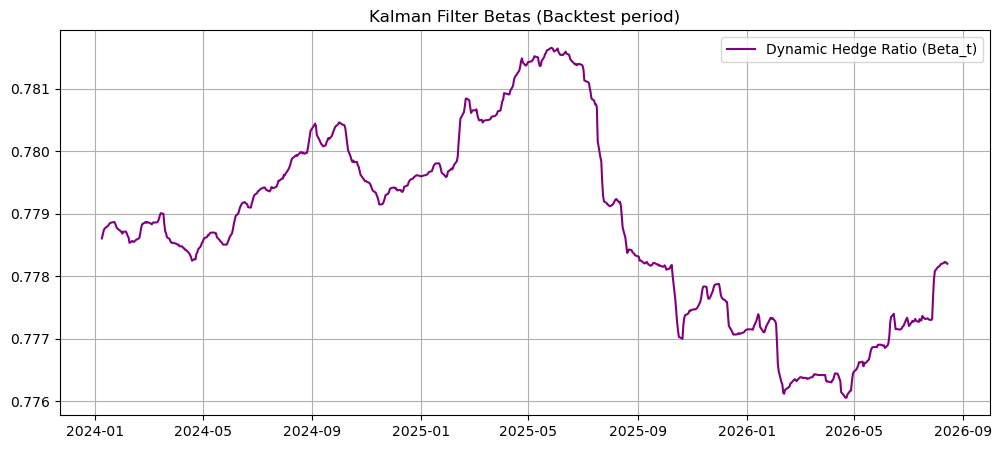

In [112]:
# Plot the dynamic hedge ratio from the regularized state space model
backtest_index = log_prices_test.index[param_est_size:]
plt.figure(figsize=(12, 5))
plt.plot(backtest_index, backtest_betas_series, label="Dynamic Hedge Ratio (Beta_t)", color="purple")
plt.title("Kalman Filter Betas (Backtest period)")
plt.legend()
plt.grid(True)
plt.show()